# Baseline VAE — experiments: paper-like vs moderate latent

This notebook reproduces the preprocessing from `Baseline_VAE.ipynb` (MAX_LEN=60, train-only vocab) and adds two experiment configs: (A) paper-like complexity, (B) moderate (latent=128).

In [4]:
import deepchem as dc
from rdkit import Chem
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

print('torch', torch.__version__)

torch 2.10.0


In [6]:
# Force re-download / re-featurize and save cache to a stable folder
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer="Raw",
    reload=True,
    data_dir="data",            # where raw data is stored
    save_dir="data/tox21-cache" # where featurized/cache files are written
)
train_dataset, valid_dataset, test_dataset = datasets

train_smiles = [Chem.MolToSmiles(mol) for mol in train_dataset.X]
valid_smiles = [Chem.MolToSmiles(mol) for mol in valid_dataset.X]
test_smiles  = [Chem.MolToSmiles(mol) for mol in test_dataset.X]

print('raw counts:', len(train_smiles), len(valid_smiles), len(test_smiles))

raw counts: 6258 782 783


In [7]:
# Use the same MAX_LEN as your Baseline notebook
MAX_LEN = 60
def filter_by_len(smiles_list, max_len=MAX_LEN):
    return [s for s in smiles_list if len(s) <= max_len]

train_smiles = filter_by_len(train_smiles)
valid_smiles = filter_by_len(valid_smiles)
test_smiles  = filter_by_len(test_smiles)
print('kept counts:', len(train_smiles), len(valid_smiles), len(test_smiles))

kept counts: 5721 577 597


In [8]:
PAD = '<PAD>'
UNK = '<UNK>'
EOS = '<EOS>'
all_chars = [PAD, UNK, EOS] + sorted(set(''.join(train_smiles)))
char_to_idx = {c: i for i, c in enumerate(all_chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
EOS_IDX = char_to_idx[EOS]

def tokenize_smiles(smiles, char_to_idx, unk_token=UNK, eos_idx=EOS_IDX):
    unk_idx = char_to_idx[unk_token]
    token_ids = [char_to_idx.get(c, unk_idx) for c in smiles]
    token_ids.append(eos_idx)
    return token_ids

train_tokenized = [tokenize_smiles(s, char_to_idx) for s in train_smiles]
valid_tokenized = [tokenize_smiles(s, char_to_idx) for s in valid_smiles]
test_tokenized  = [tokenize_smiles(s, char_to_idx) for s in test_smiles]

vocab_size = len(all_chars)
seq_len = max(len(s) for s in train_tokenized)
print('vocab_size, seq_len:', vocab_size, seq_len)

vocab_size, seq_len: 54 61


In [9]:
def one_hot(seq, seq_len, vocab_size, pad_idx=0):
    mat = np.zeros((seq_len, vocab_size), dtype=np.float32)
    mat[:, pad_idx] = 1.0
    for j, idx in enumerate(seq):
        if j >= seq_len:
            break
        mat[j, pad_idx] = 0.0
        mat[j, idx] = 1.0
    return mat

def one_hot_encode_split(encoded_list):
    X = np.array([one_hot(seq, seq_len, vocab_size) for seq in encoded_list], dtype=np.float32)
    return X

train_one_hot = one_hot_encode_split(train_tokenized)
valid_one_hot = one_hot_encode_split(valid_tokenized)
test_one_hot  = one_hot_encode_split(test_tokenized)

print('shapes:', train_one_hot.shape, valid_one_hot.shape, test_one_hot.shape)

shapes: (5721, 61, 54) (577, 61, 54) (597, 61, 54)


In [10]:
def decode_one_hot(x_vocab_seq, idx_to_char, pad_char='<PAD>', eos_char='<EOS>'):
    token_ids = x_vocab_seq.argmax(axis=0)
    out_chars = []
    for i in token_ids:
        ch = idx_to_char[int(i)]
        if ch == eos_char:
            break
        if ch == pad_char:
            continue
        out_chars.append(ch)
    return ''.join(out_chars).strip()

print('example decode:')
print(decode_one_hot(train_one_hot[0].T, idx_to_char))

example decode:
CC(O)(P(=O)(O)O)P(=O)(O)O


In [11]:
class ExperimentVAE(nn.Module):
    def __init__(self, vocab_size, seq_len, latent_dim=292, enc_hidden=435, dec_input=None,
                 gru_hidden=501, gru_layers=3):
        super().__init__()
        self.seq_len = seq_len
        self.conv_1 = nn.Conv1d(in_channels=seq_len, out_channels=9, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()
        # infer flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, seq_len, vocab_size)
            d = dummy
            d = self.relu(self.conv_1(d))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            flattened = d.view(1, -1).size(1)
        self.linear_0 = nn.Linear(flattened, enc_hidden)
        self.linear_1 = nn.Linear(enc_hidden, latent_dim)
        self.linear_2 = nn.Linear(enc_hidden, latent_dim)
        dec_input = dec_input or latent_dim
        self.linear_3 = nn.Linear(latent_dim, dec_input)
        self.gru = nn.GRU(input_size=dec_input, hidden_size=gru_hidden, num_layers=gru_layers, batch_first=True)
        self.linear_4 = nn.Linear(gru_hidden, vocab_size)

    def encoder(self, x):
        x = self.relu(self.conv_1(x))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.view(x.size(0), -1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, z_mean, z_logvar):
        epsilon = 1e-2 * torch.randn_like(z_logvar)
        return torch.exp(0.5 * z_logvar) * epsilon + z_mean

    def decode(self, z):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        out_reshape = out.contiguous().view(-1, out.size(-1))
        y0 = F.softmax(self.linear_4(out_reshape), dim=1)
        y = y0.contiguous().view(out.size(0), -1, y0.size(-1))
        return y

    def forward(self, x):
        z_mean, z_logvar = self.encoder(x)
        z = self.sampling(z_mean, z_logvar)
        return self.decode(z), z_mean, z_logvar


In [12]:
def vae_loss_bce(pred_probs, x_onehot, z_mean, z_logvar):
    recon = F.binary_cross_entropy(pred_probs, x_onehot, reduction='sum')
    kl = -0.5 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())
    return recon + kl

def train_and_eval(model, train_X, valid_X, device, epochs=30, batch_size=250, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(TensorDataset(torch.from_numpy(train_X).float()), batch_size=batch_size, shuffle=True, drop_last=True)
    valid_loader = DataLoader(TensorDataset(torch.from_numpy(valid_X).float()), batch_size=batch_size, shuffle=False)
    train_losses, val_losses = [], []
    for ep in range(1, epochs+1):
        model.train()
        tsum = 0.0
        for batch in train_loader:
            x = batch[0].to(device)
            opt.zero_grad()
            preds, mean, logvar = model(x)
            loss = vae_loss_bce(preds, x, mean, logvar)
            loss.backward()
            opt.step()
            tsum += loss.item()
        train_losses.append(tsum / len(train_loader.dataset))
        model.eval()
        vsum = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[0].to(device)
                preds, mean, logvar = model(x)
                vsum += vae_loss_bce(preds, x, mean, logvar).item()
        val_losses.append(vsum / len(valid_loader.dataset))
        print(f'Ep {ep}: train={train_losses[-1]:.4f} val={val_losses[-1]:.4f}')
    return {'model': model, 'train_losses': train_losses, 'val_losses': val_losses}

def sample_and_decode(model, device, n=5):
    model.eval()
    with torch.no_grad():
        z_dim = model.linear_3.in_features
        z = torch.randn(n, z_dim).to(device) * 0.01
        probs = model.decode(z)
        probs = probs.cpu().numpy()
    samples = [decode_one_hot(probs[i].T, idx_to_char) for i in range(n)]
    return samples


Ep 1: train=167.2273 val=188.7747
Ep 2: train=124.4304 val=181.0586
Ep 3: train=106.6941 val=148.8158
Ep 4: train=95.1639 val=147.9269
Ep 5: train=94.3802 val=144.9491
Ep 6: train=90.1075 val=139.1303
Ep 7: train=91.7815 val=138.4178
Ep 8: train=88.2025 val=144.9612
Ep 9: train=90.9726 val=139.2700
Ep 10: train=87.0604 val=133.9747
Ep 11: train=86.8546 val=134.4226
Ep 12: train=85.7653 val=135.0953
Ep 13: train=85.6658 val=134.2477
Ep 14: train=85.1513 val=133.2062
Ep 15: train=85.0016 val=132.5410
Ep 16: train=91.2773 val=144.5281
Ep 17: train=87.0670 val=134.5272
Ep 18: train=83.8532 val=134.6456
Ep 19: train=88.1942 val=133.1120
Ep 20: train=85.6009 val=134.1461
Ep 21: train=82.9877 val=132.3391
Ep 22: train=84.1719 val=131.7792
Ep 23: train=83.3582 val=133.4840
Ep 24: train=82.9787 val=131.0074
Ep 25: train=81.9658 val=128.2599
Ep 26: train=83.8385 val=131.9783
Ep 27: train=79.6805 val=127.1184
Ep 28: train=78.8934 val=127.2092
Ep 29: train=78.6838 val=127.6813
Ep 30: train=81.5551

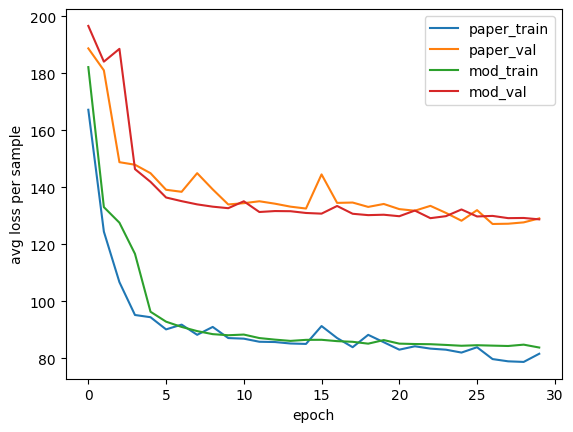

In [13]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Paper-like config
paper_cfg = dict(vocab_size=vocab_size, seq_len=seq_len,
                 latent_dim=292, enc_hidden=435, dec_input=292, gru_hidden=501, gru_layers=3)
model_paper = ExperimentVAE(**paper_cfg)
hist_paper = train_and_eval(model_paper, train_one_hot, valid_one_hot, device,
                           epochs=30, batch_size=250, lr=1e-3)
print('Paper-like samples:')
print(sample_and_decode(hist_paper['model'], device, n=5))

# Moderate config
mod_cfg = dict(vocab_size=vocab_size, seq_len=seq_len,
               latent_dim=128, enc_hidden=435, dec_input=128, gru_hidden=384, gru_layers=3)
model_mod = ExperimentVAE(**mod_cfg)
hist_mod = train_and_eval(model_mod, train_one_hot, valid_one_hot, device,
                          epochs=30, batch_size=64, lr=1e-4)
print('Moderate samples:')
print(sample_and_decode(hist_mod['model'], device, n=5))

plt.figure()
plt.plot(hist_paper['train_losses'], label='paper_train')
plt.plot(hist_paper['val_losses'], label='paper_val')
plt.plot(hist_mod['train_losses'], label='mod_train')
plt.plot(hist_mod['val_losses'], label='mod_val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('avg loss per sample')
plt.show()


In [15]:
def show_test_predictions(model, test_one_hot, test_smiles, idx_to_char, device, n=5, seed=42):
    model.eval()
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(test_one_hot), size=n, replace=False)
    X = torch.from_numpy(test_one_hot[idxs]).float().to(device)
    with torch.no_grad():
        preds, _, _ = model(X)  # (B, seq_len, vocab)
    preds_np = preds.cpu().numpy()
    for i, idx in enumerate(idxs):
        orig = test_smiles[idx]
        pred_smiles = decode_one_hot(preds_np[i].T, idx_to_char)
        print(f"[{i}] original: {orig}")
        print(f"    predicted: {pred_smiles}\n")

# Run for paper-like model
print('Paper-like model predictions:')
show_test_predictions(hist_paper['model'], test_one_hot, test_smiles, idx_to_char, device, n=5, seed=0)

# Run for moderate model
print('Moderate model predictions:')
show_test_predictions(hist_mod['model'], test_one_hot, test_smiles, idx_to_char, device, n=5, seed=1)

Paper-like model predictions:
[0] original: O=C(O)c1snc(Cl)c1Cl
    predicted: CCC(ccccccccccccc1

[1] original: CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl
    predicted: CCCCccccccccccccccccccccccccccccccccccc

[2] original: CN1CCC[C@@H]1Cc1c[nH]c2ccc(CCS(=O)(=O)c3ccccc3)cc12
    predicted: CCC(cccccccccccccccccccccccccccccccccccccccccccc

[3] original: COc1cc(S(C)=O)ccc1-c1nc2ncccc2[nH]1
    predicted: CCC(ccccccccccccccccccccccccccccc1

[4] original: S=C1SCN(Cc2ccccc2)CN1Cc1ccccc1
    predicted: CCCccccccccccccccccccccccccc1

Moderate model predictions:
[0] original: CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl
    predicted: CCCCCCCCCCcccccccccccccccccccccccccccccc1

[1] original: CNS(=O)(=O)CCc1ccc2[nH]cc(C3CCN(C)CC3)c2c1
    predicted: CCCCCCCCCCcccccccccccccccccccccccccccccc1

[2] original: C[n+]1c2cc(N)ccc2cc2ccc(N)cc21.Nc1ccc2cc3ccc(N)cc3nc2c1
    predicted: CCCCCCCCCCCCCCcccccccccccccccccccccccccccccccccccccccc1

[3] original: CC1=C(C(=O)Nc2ccccc2)SCCO1
    predicted: CCCCCCCCccc